# Project 2 – Exploratory Data Analysis (EDA)

### Prepared by
**[Julian Andres Belmonte Ortiz](https://www.linkedin.com/in/julianbel/)**

### Organization
DecodeLabs – Training Program 2026

---
## Project Objective

The purpose of this Exploratory Data Analysis (EDA) project is to transform raw transactional data into actionable insights by examining its key characteristics and underlying patterns. The analysis focuses on understanding data distributions, identifying trends and anomalies, and evaluating relationships between variables through statistical methods and visual exploration.

By calculating descriptive statistics, detecting outliers, and analyzing customer purchasing behavior, this project seeks to provide a comprehensive overview of the dataset and establish a solid foundation for future analytical initiatives, reporting, and predictive modeling efforts.

---

**Import Libraries**

The required libraries are imported to perform data manipulation, statistical analysis, and data visualization.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

**Load Cleaned Dataset**

The cleaned dataset generated in Project 1 is loaded into a Pandas DataFrame for exploratory analysis.

In [46]:
df = pd.read_excel("Cleaned_Dataset_Project1.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


**Dataset Overview**

This step provides a general understanding of the dataset structure, including the number of rows, columns, and data types.

In [47]:
print(df.shape)

df.info()

(1200, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
 14  CalculatedTotal  1200 non-null   float64
dtypes: float64(3), int64(2), object(10)
memory usage: 140.8+ KB


**Descriptive Statistics**

The describe() function generates summary statistics for numerical variables, including count, mean, standard deviation, minimum, maximum, and quartiles.

In [48]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300,1053.968300
std,1.407557,197.177146,2.281983,819.856558,819.856558
min,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2.000000,186.062500,4.000000,410.520000,410.520000
50%,3.000000,364.210000,5.000000,823.615000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000,3456.400000


**Mean**

The mean represents the average value of a variable and provides insight into the central tendency of the data.

The mean values provide an overview of the typical transaction characteristics within the dataset. On average, customers purchased approximately **2.95 items per order**, indicating that most transactions involve multiple products rather than single item purchases. The average **UnitPrice** is approximately **356.41**, suggesting a moderate product price range across the catalog. Additionally, the average **TotalPrice** per transaction is **1,053.97**, which indicates that customers tend to generate relatively high value orders when combining multiple items in a single purchase.

The mean analysis suggests that the business primarily processes medium to high value transactions, with customers purchasing nearly three items per order on average. The relationship between the average quantity purchased and the average transaction value indicates that order totals are influenced not only by product prices but also by customers purchasing multiple items in the same transaction. These findings provide a useful baseline for understanding customer purchasing behavior and will support further trend and outlier analysis in subsequent stages of the Exploratory Data Analysis.

In [49]:
df[["Quantity", "UnitPrice", "TotalPrice"]].mean()

,0
Quantity,2.945833
UnitPrice,356.412750
TotalPrice,1053.968300


**Median**

The median identifies the middle value of a distribution and is less sensitive to extreme values than the mean.

The median values provide a more robust measure of central tendency because they are less affected by extreme values or unusually large transactions. The median **Quantity** is **3**, indicating that half of all orders contain three or fewer items, while the other half contain three or more items. The median **UnitPrice** is **364.21**, which is very close to the mean UnitPrice (356.41), suggesting that product prices are relatively evenly distributed with limited influence from extreme pricing values. However, the median **TotalPrice** is **823.62**, which is noticeably lower than the mean TotalPrice (1,053.97). This difference suggests that some high value transactions are increasing the average order value, indicating a right skewed distribution in transaction totals.

The median analysis confirms that a typical customer purchases approximately three items per order, with a typical product price of around 364 monetary units. The gap between the median and mean TotalPrice suggests the presence of higher value orders that raise the overall average transaction value. This is an important insight because it indicates that while most transactions fall around the median value, a smaller number of large purchases contribute significantly to overall revenue. This observation should be further explored during the outlier detection and distribution analysis phases of the EDA.

In [50]:
df[["Quantity", "UnitPrice", "TotalPrice"]].median()

,0
Quantity,3.000
UnitPrice,364.210
TotalPrice,823.615


**Count**

The count function returns the number of non-null observations for each column.

In [51]:
df.count()

,0
OrderID,1200
Date,1200
CustomerID,1200
Product,1200
Quantity,1200
UnitPrice,1200
ShippingAddress,1200
PaymentMethod,1200
OrderStatus,1200
TrackingNumber,1200


# Distribution Analysis

**Histogram - TotalPrice**

This histogram shows how sales amounts are distributed across all transactions. It helps identify concentration areas, skewness, and unusual observations.

The histogram shows the distribution of transaction values across the dataset. Most transactions are concentrated between approximately **100 and 1,000 monetary units**, with the highest frequency occurring around the **400–700 range**. As the transaction value increases, the frequency gradually decreases, indicating that high value purchases occur less frequently. The distribution is not symmetrical and exhibits a **positive (right) skew**, characterized by a long tail extending toward higher TotalPrice values. This pattern suggests that while the majority of customers make relatively moderate purchases, a smaller group of customers generates significantly larger transactions.

The distribution of TotalPrice indicates that the dataset is dominated by low to medium value transactions, while a limited number of high value orders contribute disproportionately to total revenue. The right skewed shape of the histogram supports the earlier observation that the mean TotalPrice is higher than the median TotalPrice, suggesting the presence of larger transactions that pull the average upward. These results provide evidence of potential outliers and highlight the importance of further investigating high value orders during the outlier detection phase of the Exploratory Data Analysis.

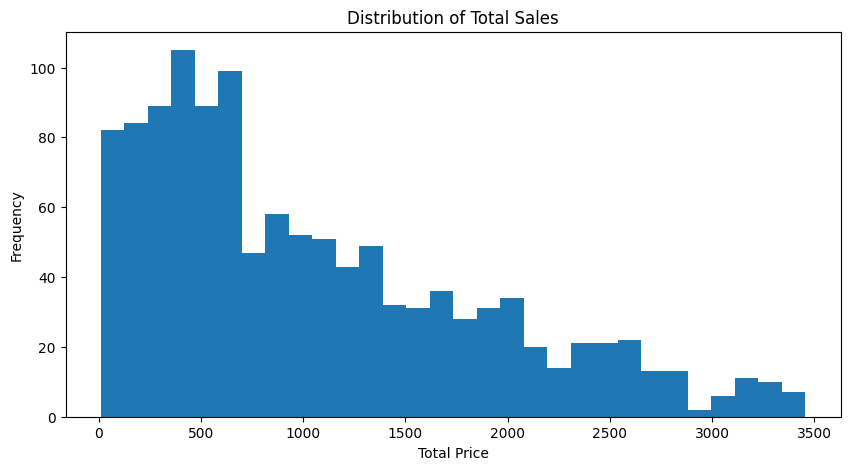

In [52]:
plt.figure(figsize=(10,5))

plt.hist(df["TotalPrice"], bins=30)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

The histogram reveals a typical business pattern where most customers generate moderate transaction amounts, while a smaller segment of customers is responsible for higher value purchases. From a business perspective, these high spending customers may represent an important revenue driving segment and could be valuable candidates for customer retention or targeted marketing strategies.

# Outlier Detection

**Boxplot**

A boxplot is used to identify potential outliers. Values located outside the whiskers may represent unusual transactions that require further investigation.

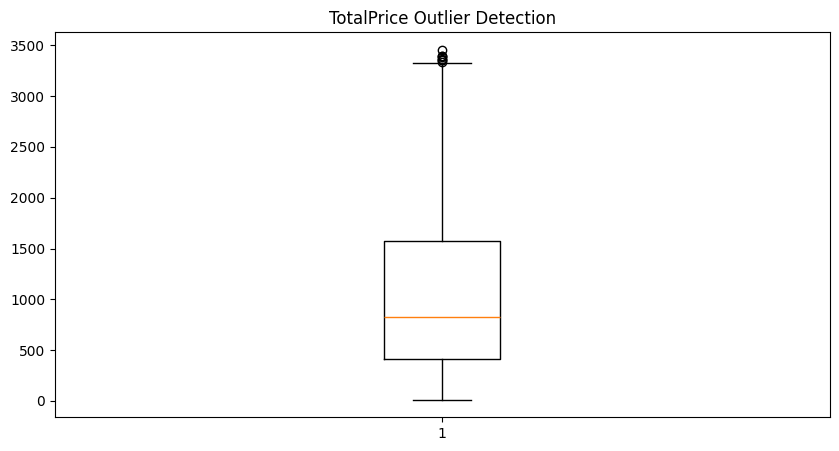

In [53]:
plt.figure(figsize=(10,5))

plt.boxplot(df["TotalPrice"])

plt.title("TotalPrice Outlier Detection")

plt.show()

**Quantify Outliers**

The Interquartile Range (IQR) method is used to identify outliers. Transactions outside the acceptable range are flagged as potential anomalies.

In [54]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[
    (df["TotalPrice"] < lower_bound) |
    (df["TotalPrice"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 8


The boxplot for TotalPrice visually identifies potential outliers as individual points beyond the whiskers. Using the Interquartile Range (IQR) method, the analysis quantitatively determined that there are **8 transactions** classified as outliers. These outliers represent unusually high TotalPrice values that fall outside the typical distribution of sales, suggesting they warrant further investigation as significant transactions that deviate from the majority.

# Sales Trend Analysis

**Monthly Sales Trend**

This visualization helps identify seasonal patterns and revenue trends throughout the year.

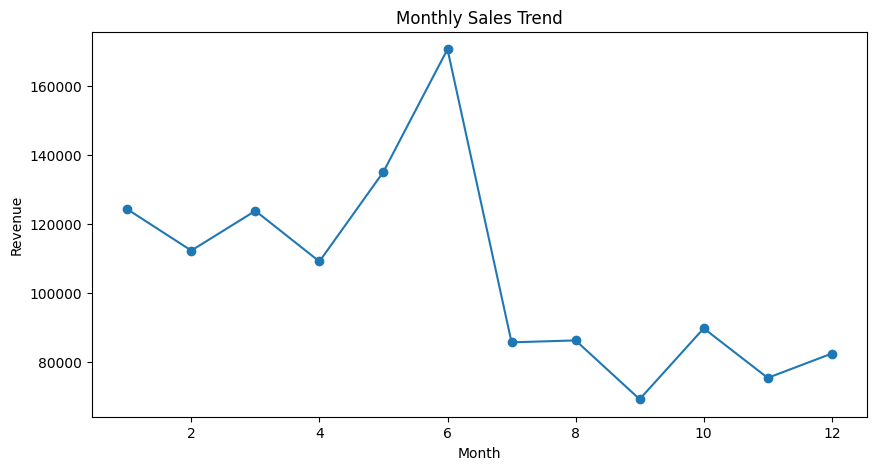

In [55]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = (
    df.groupby(df["Date"].dt.month)["TotalPrice"]
      .sum()
)

monthly_sales.plot(
    kind="line",
    figsize=(10,5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

The monthly sales trend analysis, visualized through a line plot, reveals significant fluctuations in revenue throughout the year, indicative of seasonal purchasing behavior. Sales generally start strong, peaking notably in June with the highest revenue, and then experience a decline, reaching their lowest point in September. This pattern suggests that business performance is not consistent across all months, highlighting periods of high demand and slower periods, which can inform inventory management, marketing campaigns, and staffing decisions.

# Category Analysis

This chart compares the revenue generated by each payment method and identifies the most commonly used payment channels.

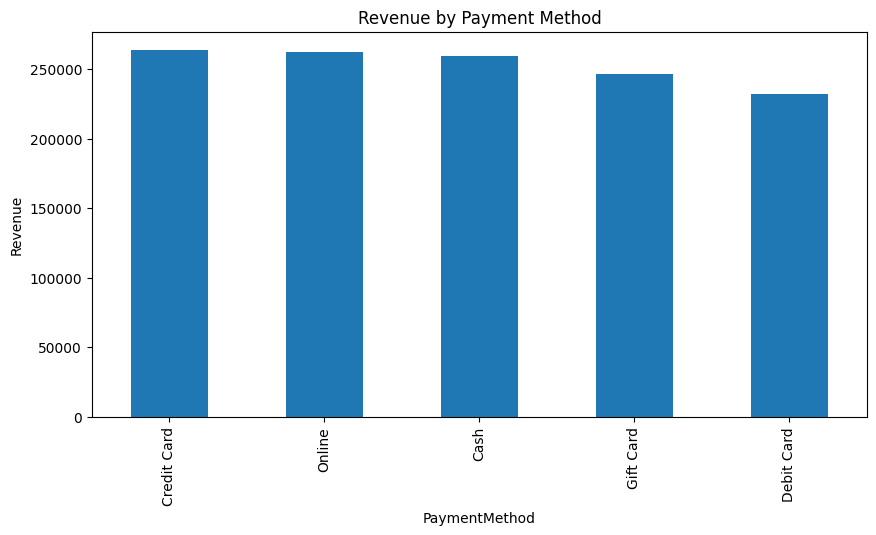

In [56]:
payment_sales = (
    df.groupby("PaymentMethod")
      ["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

payment_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")

plt.show()

The analysis of payment methods reveals a diversified revenue stream, with **Credit Card**, **Online**, and **Cash** payments contributing almost equally and forming the top three revenue generating channels. Credit Card leads slightly, followed closely by Online and Cash, each generating over 250,000 monetary units. Gift Card and Debit Card methods show slightly lower, but still substantial, contributions. This distribution suggests a healthy balance across various payment options, indicating that customers utilize a range of methods, and the business effectively captures revenue from each

# Order Status Analysis

This analysis provides insights into the operational performance of order fulfillment processes.

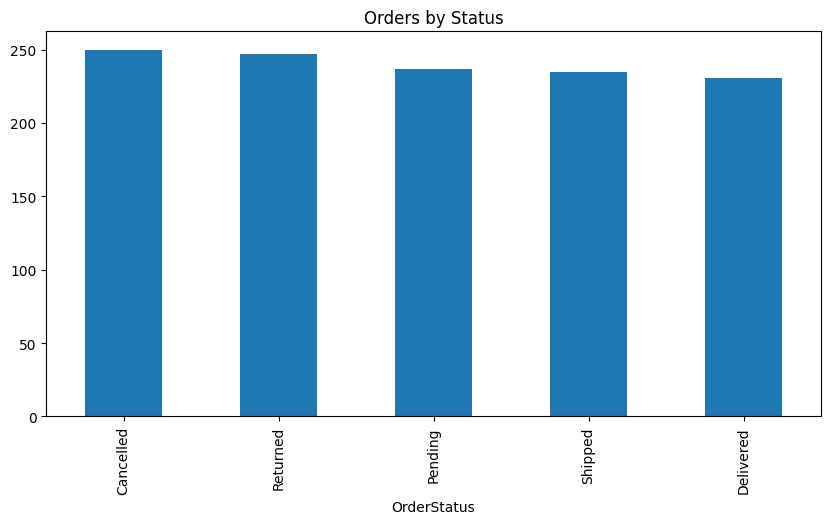

In [57]:
status_count = df["OrderStatus"].value_counts()

status_count.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Orders by Status")

plt.show()

The order status analysis reveals a relatively even distribution across different order states, with **'Cancelled'** orders being the most frequent, closely followed by **'Returned'** and **'Pending'** orders.

**'Shipped'** and **'Delivered'** orders are slightly less common compared to the other categories.

This indicates that while a significant portion of orders are successfully processed, a substantial number also face issues such as cancellations, returns, or remain pending.

This distribution suggests areas for operational improvement, particularly in reducing cancellations and returns, and optimizing the delivery process.

# Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

In [58]:
numeric_cols = [
    "Quantity",
    "UnitPrice",
    "TotalPrice"
]

corr = df[numeric_cols].corr()

print(corr)

            Quantity  UnitPrice  TotalPrice
Quantity    1.000000   0.014553    0.615251
UnitPrice   0.014553   1.000000    0.717081
TotalPrice  0.615251   0.717081    1.000000


The correlation analysis reveals strong positive relationships between **TotalPrice** and both **Quantity (0.615)** and **UnitPrice (0.717)**, indicating that higher prices and larger quantities significantly drive up the total transaction value.

Conversely, the correlation between **Quantity** and **UnitPrice** is very weak (0.015), suggesting that the number of items purchased is largely independent of their individual price. This implies that customers either buy more expensive items or more items overall, but not necessarily both simultaneously, to increase their total purchase amount.

# Key Findings

### Missing Values
No missing values were found after the cleaning process completed in Project 1, ensuring data integrity for analysis.

### Sales Distribution
The distribution of `TotalPrice` is positively skewed, indicating that while most transactions fall within a moderate range, a significant long tail of fewer, higher value purchases inflates the average `TotalPrice` above the median.

### Outlier Transactions
Through boxplot analysis and the Interquartile Range (IQR) method, 8 transactions were quantitatively identified as outliers based on their unusually high `TotalPrice`, warranting further investigation as significant deviations from typical sales.

### Revenue Trends
Monthly sales analysis revealed notable fluctuations in revenue throughout the year, peaking significantly in June and declining to a low in September, clearly suggesting strong seasonal purchasing behavior that impacts business performance.

### Payment Methods
Category analysis showed that Credit Card, Online, and Cash are the top three payment methods, contributing almost equally and forming the largest share of revenue, indicating a diversified and well utilized set of payment channels.

### Order Status
Order status analysis highlighted that 'Cancelled' orders are the most frequent, closely followed by 'Returned' and 'Pending', suggesting areas for operational improvement to reduce order issues and enhance fulfillment processes.

### Correlation Analysis
Strong positive correlations were observed between `TotalPrice` and both `Quantity` (0.615) and `UnitPrice` (0.717), implying that increasing either the number of items or their individual price effectively drives higher total revenue. A weak correlation between `Quantity` and `UnitPrice` (0.015) suggests these are largely independent factors in customer purchasing decisions.

### Data Quality
The dataset was found to be consistent, with no duplicate records, invalid dates, or pricing inconsistencies, providing a reliable foundation for advanced analytics.

# Final Conclusion

The Exploratory Data Analysis successfully identified patterns, trends, and distributions within the dataset. Descriptive statistics, distribution analysis, trend analysis, and outlier detection were performed to better understand the underlying characteristics of the data.

The analysis revealed meaningful business insights regarding sales performance, customer purchasing behavior, payment methods, and operational efficiency. The dataset is clean, reliable, and suitable for advanced analytics, dashboard development, and predictive modeling in future projects.